# ECPM — Multiplicative Cooling & Heating Models

Each model uses the **product** (×) of two change-point features as a single predictor,
fitted with one non-negative coefficient:

| Model | Type    | Equation |
|-------|---------|----------|
| **C1**  | Cooling | $\hat{E} = c \cdot (T_{ext}-T_c)^+ \times (T_{ext}-T_{int})^+$ |
| **C2**  | Cooling | $\hat{E} = c \cdot (T_{ext}-T_c)^+ \times (T_{int}-T_c)^+$ |
| **H1**  | Heating | $\hat{E} = c \cdot (T_h-T_{ext})^+ \times (T_{int}-T_{ext})^+$ |
| **H2**  | Heating | $\hat{E} = c \cdot (T_h-T_{ext})^+ \times (T_{int}-T_h)^+$ |


## 0 · Setup

In [19]:
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize  import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from pathlib         import Path

plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 10,
})

COLORS = {'C1': '#2271B5', 'C2': '#E9672A',
          'H1': '#2271B5', 'H2': '#E9672A',
          'weekday': '#2271B5', 'weekend': '#E9672A'}

print('Packages loaded.')


Packages loaded.


## 1 · Load Data

In [20]:
DATA_DIR  = Path('../Prepared_Data')
CPM_PARAM = Path('../CPM_Results/AllYears_Preprocessed_Method1')

ENERGY_CSV    = DATA_DIR  / 'KEPCO_AllYears_Preprocessed_Method1.csv'
CP_PARAMS_CSV = CPM_PARAM / 'KEPCO_Yearly_CPM_Parameters.csv'

df = pd.read_csv(ENERGY_CSV)
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
df = df.dropna(subset=['electricity_kWh', 'temp_external', 'temp_internal', 'is_weekend'])
df = df.sort_values('datetime').reset_index(drop=True)
df['is_weekend'] = df['is_weekend'].astype(int)
df['day_type']   = df['is_weekend'].map({0: 'weekday', 1: 'weekend'})

floor_area_m2 = (df['electricity_kWh'] * 1000 / df['EUI_Wh_m2']).median()

cp = pd.read_csv(CP_PARAMS_CSV)
# ── Normalise column names (handles 'Year', 'tau_c', 'Weekdays' variants) ────
for c in cp.columns:
    if c.lower() == 'year' and c != 'year':
        cp = cp.rename(columns={c: 'year'}); break
if 'Tc' not in cp.columns and 'tau_c' in cp.columns:
    cp = cp.rename(columns={'tau_c': 'Tc', 'tau_h': 'Th'})
cp['day_type'] = cp['day_type'].str.lower().str.strip().str.rstrip('s')
cp['year']     = cp['year'].astype(str)

print(f'Total rows : {len(df)}')
print(f'Date range : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Years      : {sorted(df["year"].unique())}')
print(f'Floor area : {floor_area_m2:.1f} m²')
print()
print('CPM parameters loaded:')
print(cp[['year','day_type','Tc','Th','alpha']].to_string(index=False))


Total rows : 763
Date range : 2020-04-17 → 2025-08-25
Years      : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Floor area : 5381.0 m²

CPM parameters loaded:
year day_type        Tc        Th    alpha
2020  weekday 19.850957 15.717472 8.088002
2021  weekday 19.279155 16.050205 8.088256
2022  weekday 19.103497 15.605047 8.571796
2023  weekday 19.000000 17.471349 8.558636
2024  weekday 19.000000 18.000000 8.176988
2025  weekday 19.003527 14.920923 9.222514
2020  weekend 23.413117 17.999618 4.986828
2021  weekend 24.571534 17.565248 4.883707
2022  weekend 19.000000  8.005670 5.385289
2023  weekend 30.000000 18.000000 5.738792
2024  weekend 19.000000  9.092424 5.482651
2025  weekend 22.517239 14.891419 5.808324


## 2 · Helper Functions

In [21]:
def rplus(x):
    """Positive-part operator: max(0, x)."""
    return np.maximum(x, 0)


def get_cp(year_key, day_type):
    """Return (Tc, Th, Eb_kWh) for a given year / day_type."""
    if year_key == 'all':
        rows = cp[cp['day_type'] == day_type]
        if rows.empty:
            raise ValueError(f"No cp_params for day_type='{day_type}'")
        if 'n_samples' in rows.columns:
            w  = rows['n_samples'].values.astype(float)
            Tc = float(np.average(rows['Tc'].values,    weights=w))
            Th = float(np.average(rows['Th'].values,    weights=w))
            Eb = float(np.average(rows['alpha'].values, weights=w)) * floor_area_m2 / 1000
        else:
            Tc = float(rows['Tc'].mean())
            Th = float(rows['Th'].mean())
            Eb = float(rows['alpha'].mean()) * floor_area_m2 / 1000
        return Tc, Th, Eb
    row = cp[(cp['year'] == str(year_key)) & (cp['day_type'] == day_type)]
    if row.empty:
        raise ValueError(f"No cp_params for year='{year_key}', day_type='{day_type}'")
    return (float(row['Tc'].values[0]),
            float(row['Th'].values[0]),
            float(row['alpha'].values[0]) * floor_area_m2 / 1000)


def get_subset(df_full, year_key, day_type):
    """Filter dataframe by year and day_type."""
    sub = df_full.copy()
    if year_key != 'all':
        sub = sub[sub['year'] == int(year_key)]
    return sub[sub['day_type'] == day_type].reset_index(drop=True)


def compute_metrics(y_actual, y_pred, n_params):
    """Goodness-of-fit metrics (same formula as 31-model code)."""
    n      = len(y_actual)
    r2     = r2_score(y_actual, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_actual, y_pred))
    ssr    = np.sum((y_actual - y_pred) ** 2)
    cvrmse = rmse / (np.mean(y_actual) + 1e-12) * 100
    nmbe   = np.mean(y_pred - y_actual) / (np.mean(y_actual) + 1e-12) * 100
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(n - n_params - 1, 1)
    aic    = n * np.log(ssr / n + 1e-12) + 2 * n_params
    bic    = n * np.log(ssr / n + 1e-12) + n_params * np.log(n)
    return dict(R2=r2, Adj_R2=adj_r2, RMSE=rmse,
                CV_RMSE_pct=cvrmse, NMBE_pct=nmbe,
                AIC=aic, BIC=bic)


def fit_mult_model(X_prod, E_actual):
    """
    Fit the MULTIPLICATIVE model:  E = c * X_prod
    where X_prod = (feature_A)+ × (feature_B)+  (element-wise product).
    One non-negative coefficient c is fitted via curve_fit TRF.
    Returns (c, E_pred, metrics_dict, status).
    """
    n = len(E_actual)
    def model(_, c):
        return c * X_prod
    try:
        popt, _ = curve_fit(model, np.zeros(n), E_actual,
                            p0=[1.0], bounds=(0, np.inf),
                            method='trf', maxfev=20000)
        c      = float(popt[0])
        E_pred = model(None, c)
        mets   = compute_metrics(E_actual, E_pred, n_params=1)
        mets['ASHRAE_pass'] = (mets['CV_RMSE_pct'] <= 25) and (abs(mets['NMBE_pct']) <= 5)
        return c, E_pred, mets, 'OK'
    except Exception as e:
        return np.nan, np.full(n, np.nan), {}, f'FAILED: {e}'


print('Helper functions defined.')


Helper functions defined.


## 3 · Cooling Model Definitions

$$\hat{E}_{C1} = c_1 \cdot \underbrace{(T_{ext}-T_c)^+}_{\text{cooling degree}} \times \underbrace{(T_{ext}-T_{int})^+}_{\text{heat gain from outside}}$$

$$\hat{E}_{C2} = c_2 \cdot \underbrace{(T_{ext}-T_c)^+}_{\text{cooling degree}} \times \underbrace{(T_{int}-T_c)^+}_{\text{indoor heat stress}}$$

**C1** mirrors the original ECPM cooling equation terms directly.
**C2** captures the combined stress when both outdoor and indoor temperatures exceed the cooling setpoint.


In [22]:
# ── Cooling product-feature builders ─────────────────────────────────────────
COOL_MODELS = {
    'C1': {
        'label'   : '(Text-Tc)+ x (Text-Tint)+',
        'factors' : ['(Text-Tc)+', '(Text-Tint)+'],
        'desc'    : 'ECPM terms: outdoor cooling degree × heat gain through envelope',
    },
    'C2': {
        'label'   : '(Text-Tc)+ x (Tint-Tc)+',
        'factors' : ['(Text-Tc)+', '(Tint-Tc)+'],
        'desc'    : 'Combined: outdoor cooling degree × indoor heat stress above setpoint',
    },
}

def build_C1(T_ext, T_int, Tc):
    """Product feature for C1: (Text-Tc)+ x (Text-Tint)+"""
    return rplus(T_ext - Tc) * rplus(T_ext - T_int)   # element-wise ×

def build_C2(T_ext, T_int, Tc):
    """Product feature for C2: (Text-Tc)+ x (Tint-Tc)+"""
    return rplus(T_ext - Tc) * rplus(T_int - Tc)       # element-wise ×

COOL_BUILDERS = {'C1': build_C1, 'C2': build_C2}

print('Cooling multiplicative features:')
for m, info in COOL_MODELS.items():
    print(f'  {m}: E = c · {info["label"]}')
    print(f'       {info["desc"]}')


Cooling multiplicative features:
  C1: E = c · (Text-Tc)+ x (Text-Tint)+
       ECPM terms: outdoor cooling degree × heat gain through envelope
  C2: E = c · (Text-Tc)+ x (Tint-Tc)+
       Combined: outdoor cooling degree × indoor heat stress above setpoint


## 4 · Cooling-Period Filter

In [23]:
def get_cooling_subset(df_full, year_key, day_type):
    """
    Return cooling-active rows (T_ext > Tc AND kWh > Eb) + CPM params.
    For year_key='all': pools per-year cooling days using each year's own Tc/Eb
    so that n_all == sum(n_individual_years).
    """
    Tc, Th, Eb = get_cp(year_key, day_type)

    if year_key != 'all':
        sub  = get_subset(df_full, year_key, day_type)
        mask = (sub['temp_external'] > Tc) & (sub['electricity_kWh'] > Eb)
        return sub[mask].reset_index(drop=True), Tc, Th, Eb

    year_rows = cp[(cp['day_type'] == day_type) & (cp['year'] != 'all')]
    frames = []
    for _, row in year_rows.iterrows():
        yr_i   = int(row['year'])
        Tc_i   = float(row['Tc'])
        Eb_i   = float(row['alpha']) * floor_area_m2 / 1000
        sub_i  = get_subset(df_full, yr_i, day_type)
        mask_i = (sub_i['temp_external'] > Tc_i) & (sub_i['electricity_kWh'] > Eb_i)
        frames.append(sub_i[mask_i])
    if not frames:
        return pd.DataFrame(), Tc, Th, Eb
    return pd.concat(frames, ignore_index=True), Tc, Th, Eb


for dt in ['weekday', 'weekend']:
    try:
        s, Tc, _, Eb = get_cooling_subset(df, 'all', dt)
        print(f'  {dt}: {len(s)} cooling days  (Tc={Tc:.1f}°C, Eb={Eb:.3f} kWh)')
    except Exception as e:
        print(f'  {dt}: {e}')


  weekday: 241 cooling days  (Tc=19.2°C, Eb=45.184 kWh)
  weekend: 44 cooling days  (Tc=22.9°C, Eb=28.366 kWh)


## 4b · Cooling EDA — Net Electricity vs Each Feature

Scatter plots of net cooling electricity against each individual temperature feature used in models C1 and C2.
Vertical dashed line marks zero (change-point threshold).

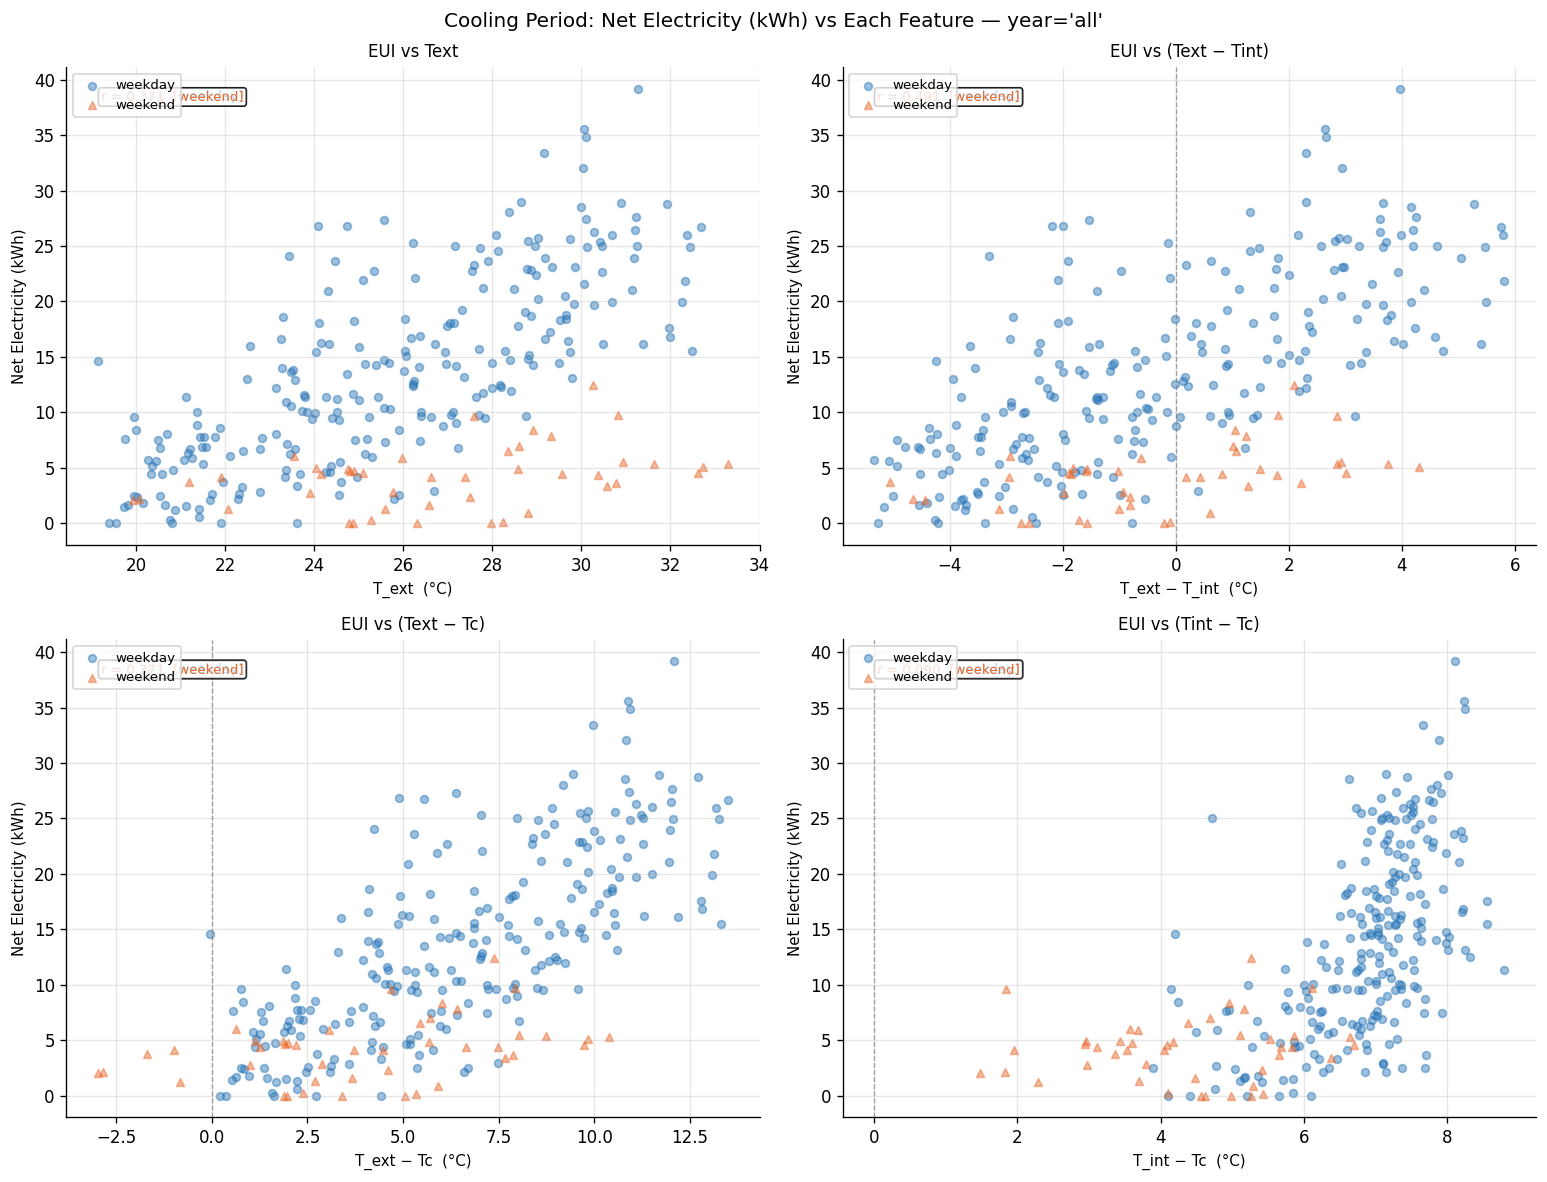

Saved: mult_cooling_EDA_scatter.png


In [24]:
# ── EDA: Cooling EUI scatter vs each feature (year_key=all) ─────────────────
from scipy.stats import pearsonr

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Cooling Period: Net Electricity (kWh) vs Each Feature — year='all'",
             fontsize=12)

for day_type, marker, col in [('weekday','o','#2271B5'),('weekend','^','#E9672A')]:
    try:
        sub, Tc, Th, Eb = get_cooling_subset(df, 'all', day_type)
    except:
        continue
    T_ext = sub['temp_external'].values
    T_int = sub['temp_internal'].values
    Ec    = np.maximum(sub['electricity_kWh'].values - Eb, 0)

    features = [
        (T_ext,            'T_ext  (°C)',          'EUI vs Text'),
        (T_ext - T_int,    'T_ext − T_int  (°C)',  'EUI vs (Text − Tint)'),
        (T_ext - Tc,       'T_ext − Tc  (°C)',     'EUI vs (Text − Tc)'),
        (T_int - Tc,       'T_int − Tc  (°C)',     'EUI vs (Tint − Tc)'),
    ]

    for ax, (xvals, xlabel, title) in zip(axes.flat, features):
        ax.scatter(xvals, Ec, alpha=0.45, s=22, color=col,
                   marker=marker, label=day_type)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Net Electricity (kWh)', fontsize=9)
        ax.set_title(title, fontsize=10)

        # Pearson r annotation
        if len(xvals) > 2:
            r_val, _ = pearsonr(xvals, Ec)
            ax.text(0.05, 0.93, f'r = {r_val:.3f}  [{day_type}]',
                    transform=ax.transAxes, fontsize=8,
                    color=col,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Add vertical zero line on difference plots
for ax_i in [1, 2, 3]:
    axes.flat[ax_i].axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.7)

for ax in axes.flat:
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('mult_cooling_EDA_scatter.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved: mult_cooling_EDA_scatter.png')


## 5 · Fit Cooling Models C1 & C2

In [25]:
YEAR_KEYS = ['all', 2021, 2022, 2023, 2024]

cool_results = {}   # { year_key : { day_type : { model_id : result_dict } } }

for YEAR_KEY in YEAR_KEYS:
    cool_results[YEAR_KEY] = {}
    print(f'\n{"#"*65}  YEAR: {YEAR_KEY}')

    for day_type in ['weekday', 'weekend']:
        try:
            sub_cool, Tc, Th, Eb = get_cooling_subset(df, YEAR_KEY, day_type)
        except Exception as e:
            print(f'  {day_type}: skipped — {e}'); continue

        n = len(sub_cool)
        if n < 10:
            print(f'  {day_type}: skipped — only {n} cooling rows'); continue

        T_ext     = sub_cool['temp_external'].values
        T_int     = sub_cool['temp_internal'].values
        Ec_actual = np.maximum(sub_cool['electricity_kWh'].values - Eb, 0)

        cool_results[YEAR_KEY][day_type] = {}
        print(f'\n  {day_type.upper()}  |  n={n}  Tc={Tc:.2f}°C  Eb={Eb:.3f} kWh')
        print(f'  {"Model":<6} {"Product feature":<35} {"coeff":>8} {"R²":>7} {"CV-RMSE%":>10} {"NMBE%":>8} {"AIC":>9} {"ASHRAE":>8}')
        print(f'  {"-"*95}')

        for mid, builder in COOL_BUILDERS.items():
            X_prod          = builder(T_ext, T_int, Tc)   # ← element-wise product
            c, E_pred, mets, status = fit_mult_model(X_prod, Ec_actual)

            rec = {
                'model'      : mid,
                'year'       : YEAR_KEY,
                'day_type'   : day_type,
                'n'          : n,
                'Tc'         : round(Tc, 4),
                'Eb'         : round(Eb, 4),
                'multiplicative_variable'    : COOL_MODELS[mid]['label'],
                'factors'    : COOL_MODELS[mid]['factors'],
                'coeff'      : round(c, 6) if status == 'OK' else np.nan,
                'status'     : status,
                'Ec_actual'  : Ec_actual,
                'Ec_pred'    : E_pred,
                **mets,
            }
            cool_results[YEAR_KEY][day_type][mid] = rec

            if status == 'OK':
                ashrae_str = 'PASS' if mets.get('ASHRAE_pass') else 'fail'
                print(f'  {mid:<6} {rec["multiplicative_variable"]:<35} {c:>8.4f} '
                      f'{mets["R2"]:>7.4f} {mets["CV_RMSE_pct"]:>10.2f} '
                      f'{mets["NMBE_pct"]:>8.2f} {mets["AIC"]:>9.2f} {ashrae_str:>8}')
            else:
                print(f'  {mid:<6} {rec["multiplicative_variable"]:<35} *** {status}')

print('\nCooling fitting complete.')



#################################################################  YEAR: all

  WEEKDAY  |  n=241  Tc=19.19°C  Eb=45.184 kWh
  Model  Product feature                        coeff      R²   CV-RMSE%    NMBE%       AIC   ASHRAE
  -----------------------------------------------------------------------------------------------
  C1     (Text-Tc)+ x (Text-Tint)+             0.5210 -0.7728      80.56   -55.05   1161.11     fail
  C2     (Text-Tc)+ x (Tint-Tc)+               0.2748  0.5256      41.68    -5.50    843.43     fail

  WEEKEND  |  n=44  Tc=22.91°C  Eb=28.366 kWh
  Model  Product feature                        coeff      R²   CV-RMSE%    NMBE%       AIC   ASHRAE
  -----------------------------------------------------------------------------------------------
  C1     (Text-Tc)+ x (Text-Tint)+             0.2497 -0.9618      94.09   -60.37    121.63     fail
  C2     (Text-Tc)+ x (Tint-Tc)+               0.1272 -0.4665      81.35   -32.56    108.83     fail

########################

## 6 · Cooling Results Summary

In [26]:
cool_rows = []
for yk, dt_dict in cool_results.items():
    for dt, mid_dict in dt_dict.items():
        for mid, rec in mid_dict.items():
            cool_rows.append({
                'year'        : yk,
                'day_type'    : dt,
                'model'       : rec['model'],
                'multiplicative_variable'     : rec['multiplicative_variable'],
                'n'           : rec['n'],
                'Tc'          : rec['Tc'],
                'Eb'          : rec['Eb'],
                'coeff'       : rec.get('coeff', np.nan),
                'R2'          : rec.get('R2', np.nan),
                'Adj_R2'      : rec.get('Adj_R2', np.nan),
                'CV_RMSE_pct' : rec.get('CV_RMSE_pct', np.nan),
                'NMBE_pct'    : rec.get('NMBE_pct', np.nan),
                'AIC'         : rec.get('AIC', np.nan),
                'BIC'         : rec.get('BIC', np.nan),
                'ASHRAE_pass' : rec.get('ASHRAE_pass', False),
                'status'      : rec.get('status', ''),
            })

cool_df = pd.DataFrame(cool_rows)

disp_cols = ['year','day_type','model','multiplicative_variable','n','coeff',
             'R2','Adj_R2','CV_RMSE_pct','NMBE_pct','AIC','ASHRAE_pass']

print('=== Cooling results — year_key=all ===')
display(cool_df[cool_df['year']=='all'][disp_cols].round(4))
print()
print('=== Cooling results — individual years, weekday ===')
wd = cool_df[(cool_df['day_type']=='weekday') & (cool_df['year']!='all')]
display(wd[disp_cols].round(4).sort_values(['year','model']))


=== Cooling results — year_key=all ===


,year,day_type,model,multiplicative_variable,n,coeff,R2,Adj_R2,CV_RMSE_pct,NMBE_pct,AIC,ASHRAE_pass
0,all,weekday,C1,(Text-Tc)+ x (Text-Tint)+,241,0.5210,-0.7728,-0.7802,80.5606,-55.0455,1161.1121,False
1,all,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,241,0.2748,0.5256,0.5236,41.6755,-5.4963,843.4283,False
2,all,weekend,C1,(Text-Tc)+ x (Text-Tint)+,44,0.2497,-0.9618,-1.0085,94.0863,-60.3688,121.6296,False
3,all,weekend,C2,(Text-Tc)+ x (Tint-Tc)+,44,0.1272,-0.4665,-0.5014,81.3458,-32.5595,108.8253,False



=== Cooling results — individual years, weekday ===


,year,day_type,model,multiplicative_variable,n,coeff,R2,Adj_R2,CV_RMSE_pct,NMBE_pct,AIC,ASHRAE_pass
4,2021,weekday,C1,(Text-Tc)+ x (Text-Tint)+,36,0.3912,-0.8695,-0.9245,79.6944,-61.5023,144.9821,False
5,2021,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,36,0.1845,0.7725,0.7659,27.7974,-3.6997,69.1477,False
6,2022,weekday,C1,(Text-Tc)+ x (Text-Tint)+,32,1.3451,-1.6693,-1.7583,114.2639,-90.3585,127.1387,False
7,2022,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,32,0.2297,0.4630,0.4451,51.2514,-10.9483,75.8255,False
10,2023,weekday,C1,(Text-Tc)+ x (Text-Tint)+,57,0.7631,-1.3078,-1.3498,77.8658,-53.1122,294.5143,False
11,2023,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,57,0.3020,0.5244,0.5158,35.3469,-3.9018,204.4800,False
12,2024,weekday,C1,(Text-Tc)+ x (Text-Tint)+,46,0.5462,-0.3790,-0.4103,55.2371,-31.1980,217.1686,False
13,2024,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,46,0.3047,0.6901,0.6830,26.1873,-4.7083,148.5033,False


## 7 · Cooling Visualizations

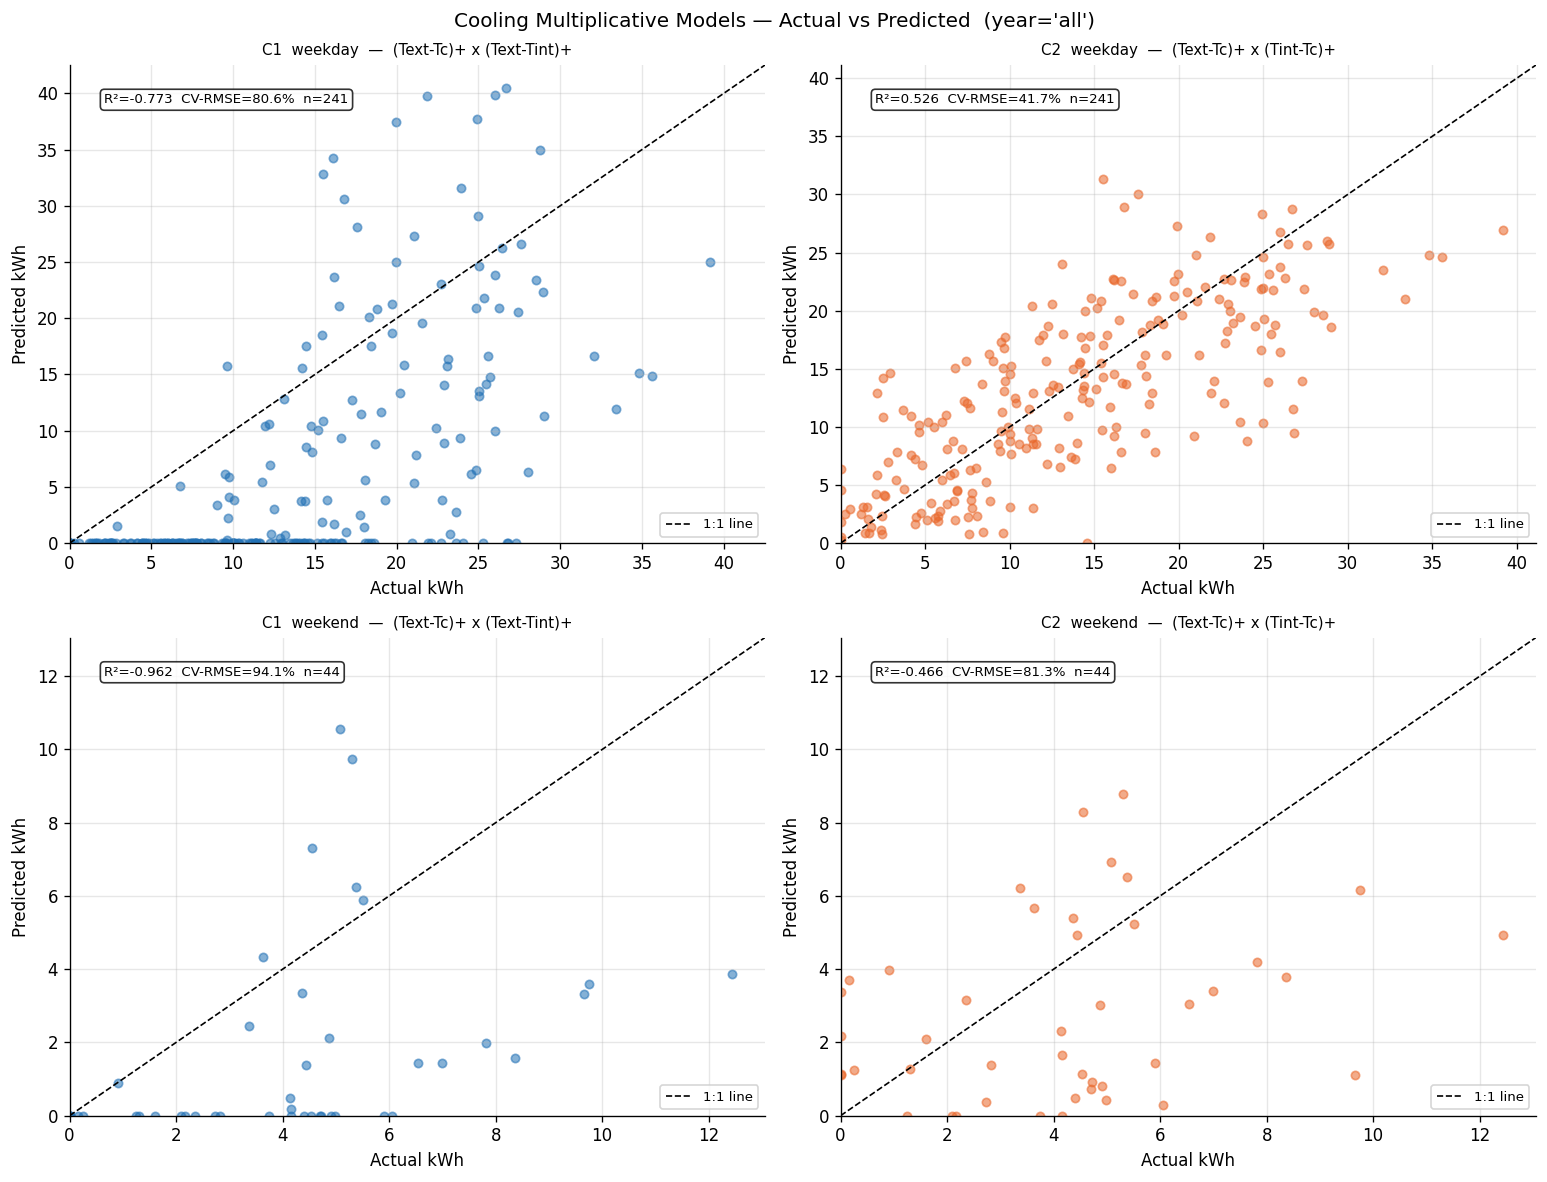

Saved: mult_cooling_scatter.png


In [27]:
# ── Scatter plots: actual vs predicted for year_key='all' ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Cooling Multiplicative Models — Actual vs Predicted  (year='all')",
             fontsize=12)

for row_i, day_type in enumerate(['weekday', 'weekend']):
    for col_i, mid in enumerate(['C1', 'C2']):
        ax = axes[row_i, col_i]
        ax.set_title(f'{mid}  {day_type}  —  {COOL_MODELS[mid]["label"]}', fontsize=9)

        if day_type not in cool_results.get('all', {}) or \
           mid not in cool_results['all'].get(day_type, {}):
            ax.set_visible(False); continue

        rec      = cool_results['all'][day_type][mid]
        Ea, Ep   = rec['Ec_actual'], rec['Ec_pred']
        r2       = rec.get('R2', np.nan)
        cvrmse   = rec.get('CV_RMSE_pct', np.nan)

        lim = max(Ea.max(), Ep.max()) * 1.05
        ax.scatter(Ea, Ep, alpha=0.55, s=25, color=COLORS[mid])
        ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
        ax.set_xlabel('Actual kWh')
        ax.set_ylabel('Predicted kWh')
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.text(0.05, 0.92, f'R²={r2:.3f}  CV-RMSE={cvrmse:.1f}%  n={rec["n"]}',
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mult_cooling_scatter.png', bbox_inches='tight')
plt.show()
print('Saved: mult_cooling_scatter.png')


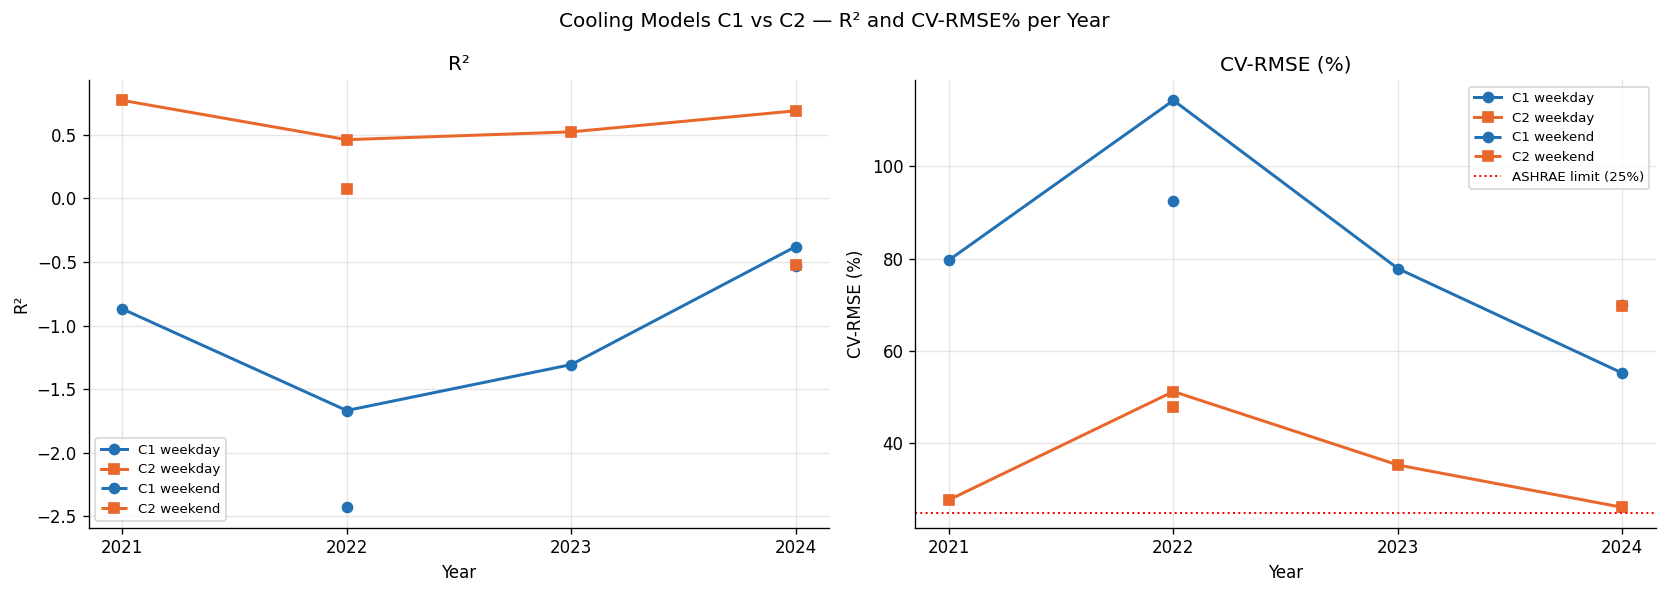

Saved: mult_cooling_R2_CVRMSE.png


In [28]:
# ── R² and CV-RMSE per year: C1 vs C2 ───────────────────────────────────────
ind_years = [y for y in YEAR_KEYS if y != 'all']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cooling Models C1 vs C2 — R² and CV-RMSE% per Year', fontsize=12)

for ax, (metric, ylabel, threshold) in zip(
        axes,
        [('R2', 'R²', None), ('CV_RMSE_pct', 'CV-RMSE (%)', 25)]):

    for day_type in ['weekday', 'weekend']:
        for mid in ['C1', 'C2']:
            vals = []
            for yr in ind_years:
                try:
                    v = cool_results[yr][day_type][mid].get(metric, np.nan)
                except KeyError:
                    v = np.nan
                vals.append(v)
            ls  = '-'  if day_type == 'weekday' else '--'
            mk  = 'o'  if mid == 'C1'           else 's'
            ax.plot(ind_years, vals, ls=ls, marker=mk, color=COLORS[mid],
                    label=f'{mid} {day_type}', linewidth=1.8, markersize=6)

    if threshold:
        ax.axhline(threshold, color='red', linestyle=':', linewidth=1.2,
                   label=f'ASHRAE limit ({threshold}%)')
    ax.set_xlabel('Year'); ax.set_ylabel(ylabel)
    ax.set_xticks(ind_years); ax.legend(fontsize=8); ax.set_title(ylabel)

plt.tight_layout()
plt.savefig('mult_cooling_R2_CVRMSE.png', bbox_inches='tight')
plt.show()
print('Saved: mult_cooling_R2_CVRMSE.png')


## 8 · Heating Model Definitions

$$\hat{E}_{H1} = c_1 \cdot \underbrace{(T_h-T_{ext})^+}_{\text{heating degree}} \times \underbrace{(T_{int}-T_{ext})^+}_{\text{heat loss rate}}$$

$$\hat{E}_{H2} = c_2 \cdot \underbrace{(T_h-T_{ext})^+}_{\text{heating degree}} \times \underbrace{(T_{int}-T_h)^+}_{\text{indoor above setpoint}}$$

**H1** captures heating when outdoor is cold AND indoor-to-outdoor heat loss is large.
**H2** captures heating when outdoor is cold AND indoor temperature exceeds the heating setpoint.


In [29]:
# ── Heating product-feature builders ─────────────────────────────────────────
HEAT_MODELS = {
    'H1': {
        'label'  : '(Th-Text)+ x (Tint-Text)+',
        'factors': ['(Th-Text)+', '(Tint-Text)+'],
        'desc'   : 'Heating degree × envelope heat loss rate',
    },
    'H2': {
        'label'  : '(Th-Text)+ x (Tint-Th)+',
        'factors': ['(Th-Text)+', '(Tint-Th)+'],
        'desc'   : 'Heating degree × indoor above heating setpoint',
    },
}

def build_H1(T_ext, T_int, Th):
    """Product feature for H1: (Th-Text)+ x (Tint-Text)+"""
    return rplus(Th - T_ext) * rplus(T_int - T_ext)   # element-wise ×

def build_H2(T_ext, T_int, Th):
    """Product feature for H2: (Th-Text)+ x (Tint-Th)+"""
    return rplus(Th - T_ext) * rplus(T_int - Th)       # element-wise ×

HEAT_BUILDERS = {'H1': build_H1, 'H2': build_H2}

print('Heating multiplicative features:')
for m, info in HEAT_MODELS.items():
    print(f'  {m}: E = c · {info["label"]}')
    print(f'       {info["desc"]}')


Heating multiplicative features:
  H1: E = c · (Th-Text)+ x (Tint-Text)+
       Heating degree × envelope heat loss rate
  H2: E = c · (Th-Text)+ x (Tint-Th)+
       Heating degree × indoor above heating setpoint


## 9 · Heating-Period Filter

In [30]:
def get_heating_subset(df_full, year_key, day_type):
    """
    Return heating-active rows (T_ext < Th AND kWh > Eb) + CPM params.
    For year_key='all': pools per-year heating days using each year's own Th/Eb.
    """
    Tc, Th, Eb = get_cp(year_key, day_type)

    if year_key != 'all':
        sub  = get_subset(df_full, year_key, day_type)
        mask = (sub['temp_external'] < Th) & (sub['electricity_kWh'] > Eb)
        return sub[mask].reset_index(drop=True), Tc, Th, Eb

    year_rows = cp[(cp['day_type'] == day_type) & (cp['year'] != 'all')]
    frames = []
    for _, row in year_rows.iterrows():
        yr_i   = int(row['year'])
        Th_i   = float(row['Th'])
        Eb_i   = float(row['alpha']) * floor_area_m2 / 1000
        sub_i  = get_subset(df_full, yr_i, day_type)
        mask_i = (sub_i['temp_external'] < Th_i) & (sub_i['electricity_kWh'] > Eb_i)
        frames.append(sub_i[mask_i])
    if not frames:
        return pd.DataFrame(), Tc, Th, Eb
    return pd.concat(frames, ignore_index=True), Tc, Th, Eb


for dt in ['weekday', 'weekend']:
    try:
        s, _, Th, Eb = get_heating_subset(df, 'all', dt)
        print(f'  {dt}: {len(s)} heating days  (Th={Th:.1f}°C, Eb={Eb:.3f} kWh)')
    except Exception as e:
        print(f'  {dt}: {e}')


  weekday: 282 heating days  (Th=16.5°C, Eb=45.184 kWh)
  weekend: 70 heating days  (Th=14.2°C, Eb=28.366 kWh)


## 9b · Heating EDA — Net Electricity vs Each Feature

Scatter plots of net heating electricity against each individual temperature feature used in models H1 and H2.
Vertical dashed line marks zero (change-point threshold).

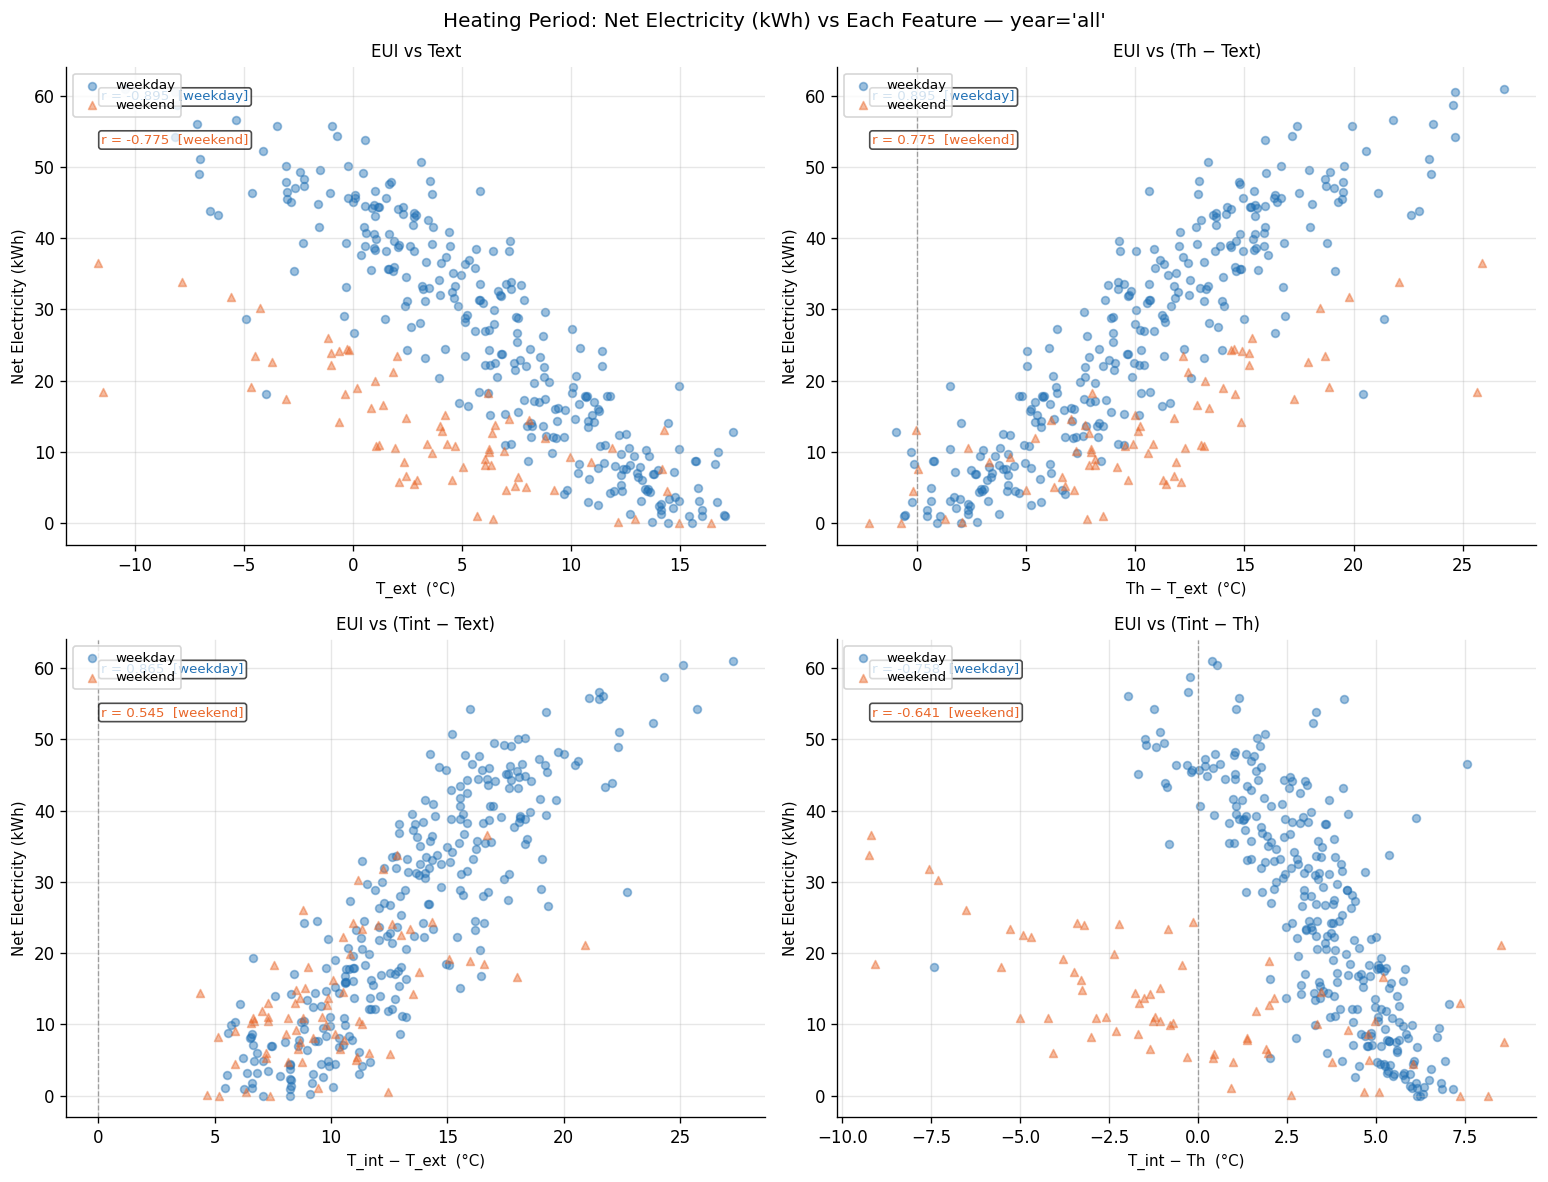

Saved: mult_heating_EDA_scatter.png


In [31]:
# ── EDA: Heating EUI scatter vs each feature (year_key=all) ─────────────────
from scipy.stats import pearsonr

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Heating Period: Net Electricity (kWh) vs Each Feature — year='all'",
             fontsize=12)

for day_type, marker, col in [('weekday','o','#2271B5'),('weekend','^','#E9672A')]:
    try:
        sub, Tc, Th, Eb = get_heating_subset(df, 'all', day_type)
    except:
        continue
    T_ext = sub['temp_external'].values
    T_int = sub['temp_internal'].values
    Eh    = np.maximum(sub['electricity_kWh'].values - Eb, 0)

    features = [
        (T_ext,            'T_ext  (°C)',          'EUI vs Text'),
        (Th - T_ext,       'Th − T_ext  (°C)',     'EUI vs (Th − Text)'),
        (T_int - T_ext,    'T_int − T_ext  (°C)',  'EUI vs (Tint − Text)'),
        (T_int - Th,       'T_int − Th  (°C)',     'EUI vs (Tint − Th)'),
    ]

    for ax, (xvals, xlabel, title) in zip(axes.flat, features):
        ax.scatter(xvals, Eh, alpha=0.45, s=22, color=col,
                   marker=marker, label=day_type)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Net Electricity (kWh)', fontsize=9)
        ax.set_title(title, fontsize=10)

        # Pearson r annotation
        if len(xvals) > 2:
            r_val, _ = pearsonr(xvals, Eh)
            # Stack r annotations vertically for weekday / weekend
            y_pos = 0.93 if day_type == 'weekday' else 0.84
            ax.text(0.05, y_pos, f'r = {r_val:.3f}  [{day_type}]',
                    transform=ax.transAxes, fontsize=8, color=col,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Add vertical zero line on difference plots
for ax_i in [1, 2, 3]:
    axes.flat[ax_i].axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.7)

for ax in axes.flat:
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('mult_heating_EDA_scatter.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved: mult_heating_EDA_scatter.png')


## 10 · Fit Heating Models H1 & H2

In [32]:
heat_results = {}

for YEAR_KEY in YEAR_KEYS:
    heat_results[YEAR_KEY] = {}
    print(f'\n{"#"*65}  YEAR: {YEAR_KEY}')

    for day_type in ['weekday', 'weekend']:
        try:
            sub_heat, Tc, Th, Eb = get_heating_subset(df, YEAR_KEY, day_type)
        except Exception as e:
            print(f'  {day_type}: skipped — {e}'); continue

        n = len(sub_heat)
        if n < 10:
            print(f'  {day_type}: skipped — only {n} heating rows'); continue

        T_ext     = sub_heat['temp_external'].values
        T_int     = sub_heat['temp_internal'].values
        Eh_actual = np.maximum(sub_heat['electricity_kWh'].values - Eb, 0)

        heat_results[YEAR_KEY][day_type] = {}
        print(f'\n  {day_type.upper()}  |  n={n}  Th={Th:.2f}°C  Eb={Eb:.3f} kWh')
        print(f'  {"Model":<6} {"Product feature":<35} {"coeff":>8} {"R²":>7} {"CV-RMSE%":>10} {"NMBE%":>8} {"AIC":>9} {"ASHRAE":>8}')
        print(f'  {"-"*95}')

        for mid, builder in HEAT_BUILDERS.items():
            X_prod              = builder(T_ext, T_int, Th)   # ← element-wise product
            c, E_pred, mets, status = fit_mult_model(X_prod, Eh_actual)

            rec = {
                'model'     : mid,
                'year'      : YEAR_KEY,
                'day_type'  : day_type,
                'n'         : n,
                'Th'        : round(Th, 4),
                'Eb'        : round(Eb, 4),
                'multiplicative_variable'   : HEAT_MODELS[mid]['label'],
                'factors'   : HEAT_MODELS[mid]['factors'],
                'coeff'     : round(c, 6) if status == 'OK' else np.nan,
                'status'    : status,
                'Eh_actual' : Eh_actual,
                'Eh_pred'   : E_pred,
                **mets,
            }
            heat_results[YEAR_KEY][day_type][mid] = rec

            if status == 'OK':
                ashrae_str = 'PASS' if mets.get('ASHRAE_pass') else 'fail'
                print(f'  {mid:<6} {rec["multiplicative_variable"]:<35} {c:>8.4f} '
                      f'{mets["R2"]:>7.4f} {mets["CV_RMSE_pct"]:>10.2f} '
                      f'{mets["NMBE_pct"]:>8.2f} {mets["AIC"]:>9.2f} {ashrae_str:>8}')
            else:
                print(f'  {mid:<6} {rec["multiplicative_variable"]:<35} *** {status}')

print('\nHeating fitting complete.')



#################################################################  YEAR: all

  WEEKDAY  |  n=282  Th=16.46°C  Eb=45.184 kWh
  Model  Product feature                        coeff      R²   CV-RMSE%    NMBE%       AIC   ASHRAE
  -----------------------------------------------------------------------------------------------
  H1     (Th-Text)+ x (Tint-Text)+             0.1372  0.5717      39.55   -14.93   1316.54     fail
  H2     (Th-Text)+ x (Tint-Th)+               0.7934 -0.5840      76.05   -23.69   1685.37     fail

  WEEKEND  |  n=70  Th=14.21°C  Eb=28.366 kWh
  Model  Product feature                        coeff      R²   CV-RMSE%    NMBE%       AIC   ASHRAE
  -----------------------------------------------------------------------------------------------
  H1     (Th-Text)+ x (Tint-Text)+             0.0956  0.3859      49.13   -15.38    264.46     fail
  H2     (Th-Text)+ x (Tint-Th)+               0.2739 -2.1949     112.05   -84.87    379.90     fail

########################

## 11 · Heating Results Summary

In [33]:
heat_rows = []
for yk, dt_dict in heat_results.items():
    for dt, mid_dict in dt_dict.items():
        for mid, rec in mid_dict.items():
            heat_rows.append({
                'year'        : yk,
                'day_type'    : dt,
                'model'       : rec['model'],
                'multiplicative_variable'     : rec['multiplicative_variable'],
                'n'           : rec['n'],
                'Th'          : rec['Th'],
                'Eb'          : rec['Eb'],
                'coeff'       : rec.get('coeff', np.nan),
                'R2'          : rec.get('R2', np.nan),
                'Adj_R2'      : rec.get('Adj_R2', np.nan),
                'CV_RMSE_pct' : rec.get('CV_RMSE_pct', np.nan),
                'NMBE_pct'    : rec.get('NMBE_pct', np.nan),
                'AIC'         : rec.get('AIC', np.nan),
                'BIC'         : rec.get('BIC', np.nan),
                'ASHRAE_pass' : rec.get('ASHRAE_pass', False),
                'status'      : rec.get('status', ''),
            })

heat_df = pd.DataFrame(heat_rows)

disp_cols = ['year','day_type','model','multiplicative_variable','n','coeff',
             'R2','Adj_R2','CV_RMSE_pct','NMBE_pct','AIC','ASHRAE_pass']

print('=== Heating results — year_key=all ===')
display(heat_df[heat_df['year']=='all'][disp_cols].round(4))
print()
print('=== Heating results — individual years, weekday ===')
wd = heat_df[(heat_df['day_type']=='weekday') & (heat_df['year']!='all')]
display(wd[disp_cols].round(4).sort_values(['year','model']))


=== Heating results — year_key=all ===


,year,day_type,model,multiplicative_variable,n,coeff,R2,Adj_R2,CV_RMSE_pct,NMBE_pct,AIC,ASHRAE_pass
0,all,weekday,H1,(Th-Text)+ x (Tint-Text)+,282,0.1372,0.5717,0.5702,39.5456,-14.9274,1316.5373,False
1,all,weekday,H2,(Th-Text)+ x (Tint-Th)+,282,0.7934,-0.5840,-0.5896,76.0516,-23.6874,1685.3699,False
2,all,weekend,H1,(Th-Text)+ x (Tint-Text)+,70,0.0956,0.3859,0.3769,49.1266,-15.3794,264.4618,False
3,all,weekend,H2,(Th-Text)+ x (Tint-Th)+,70,0.2739,-2.1949,-2.2419,112.0550,-84.8714,379.9044,False



=== Heating results — individual years, weekday ===


,year,day_type,model,multiplicative_variable,n,coeff,R2,Adj_R2,CV_RMSE_pct,NMBE_pct,AIC,ASHRAE_pass
4,2021,weekday,H1,(Th-Text)+ x (Tint-Text)+,63,0.1418,0.6714,0.6660,35.9048,-13.2415,272.9850,False
5,2021,weekday,H2,(Th-Text)+ x (Tint-Th)+,63,0.6714,-0.4009,-0.4239,74.1306,-17.5082,364.3295,False
8,2022,weekday,H1,(Th-Text)+ x (Tint-Text)+,57,0.1284,0.6143,0.6073,38.4446,-17.0844,254.6074,False
9,2022,weekday,H2,(Th-Text)+ x (Tint-Th)+,57,0.7949,-0.6770,-0.7075,80.1601,-24.6344,338.3754,False
12,2023,weekday,H1,(Th-Text)+ x (Tint-Text)+,47,0.1498,0.5804,0.5711,40.6688,-13.2512,210.4264,False
13,2023,weekday,H2,(Th-Text)+ x (Tint-Th)+,47,0.8387,-0.6100,-0.6458,79.6642,-27.8757,273.6281,False
14,2024,weekday,H1,(Th-Text)+ x (Tint-Text)+,65,0.1505,0.5924,0.5859,31.4665,-11.0606,297.3918,False
15,2024,weekday,H2,(Th-Text)+ x (Tint-Th)+,65,1.1239,-1.2661,-1.3020,74.1953,-31.8125,408.9028,False


## 12 · Heating Visualizations

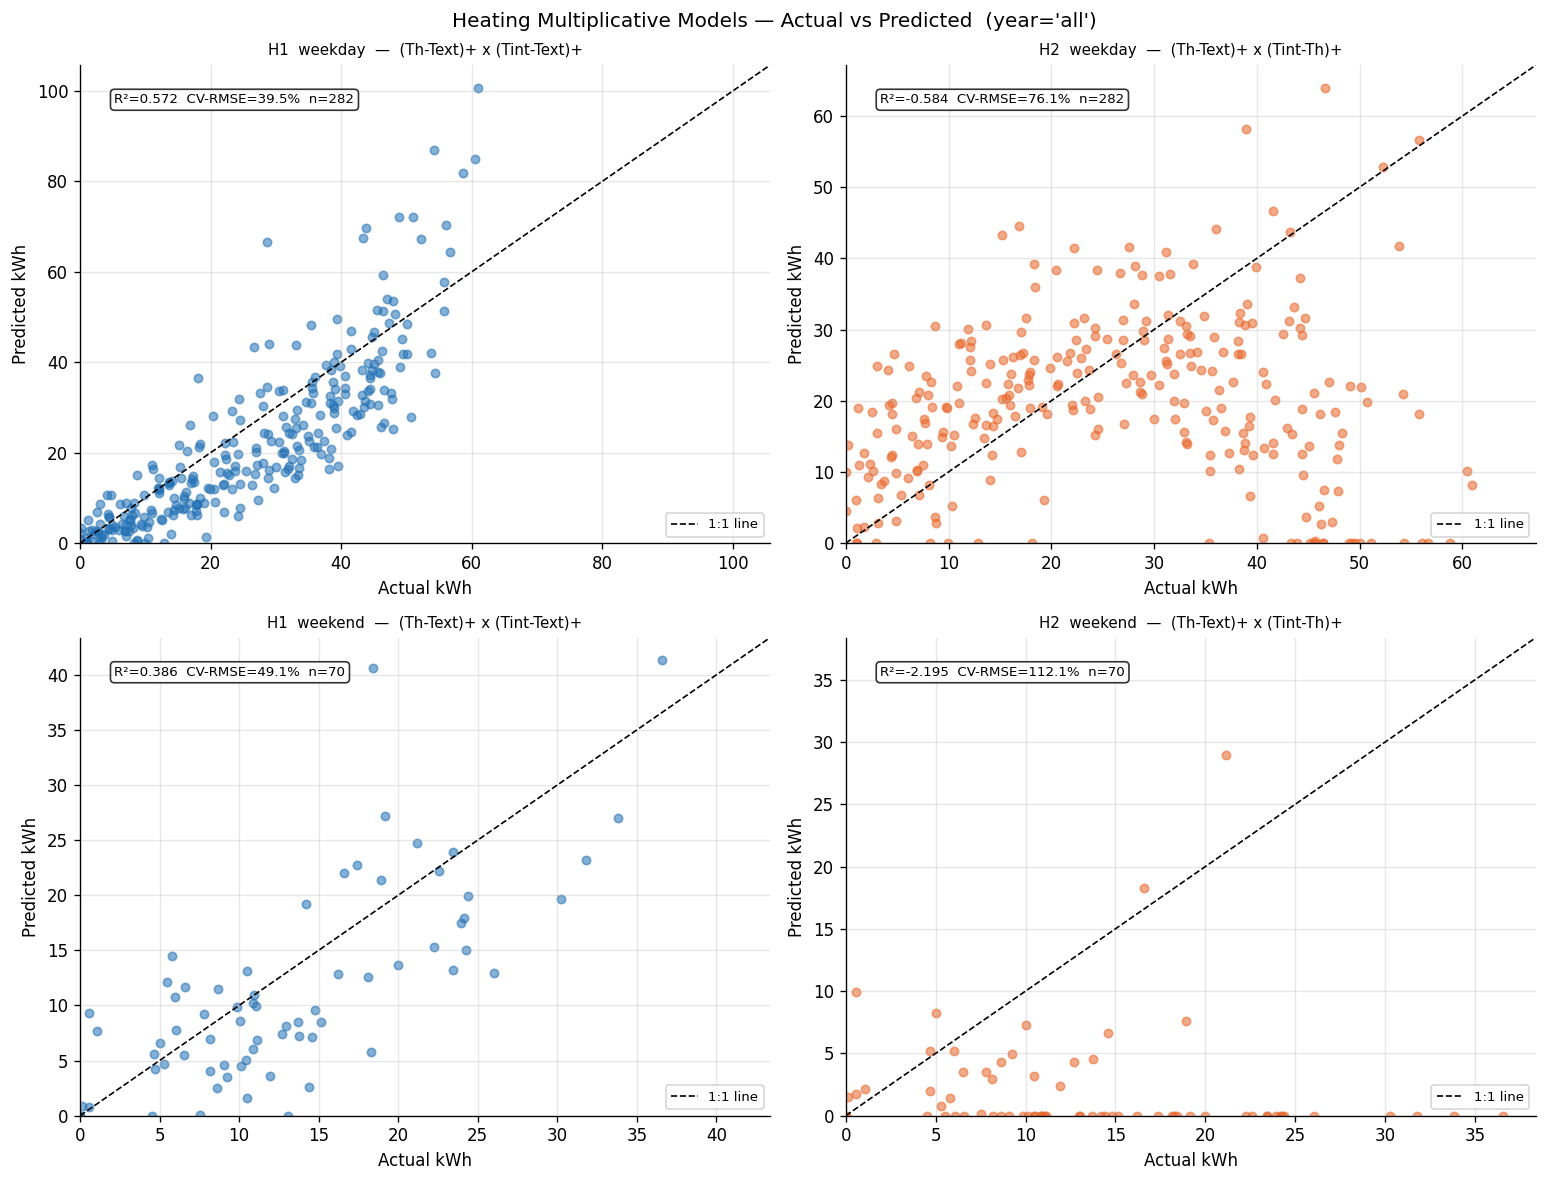

Saved: mult_heating_scatter.png


In [34]:
# ── Scatter plots: actual vs predicted for year_key='all' ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Heating Multiplicative Models — Actual vs Predicted  (year='all')",
             fontsize=12)

for row_i, day_type in enumerate(['weekday', 'weekend']):
    for col_i, mid in enumerate(['H1', 'H2']):
        ax = axes[row_i, col_i]
        ax.set_title(f'{mid}  {day_type}  —  {HEAT_MODELS[mid]["label"]}', fontsize=9)

        if day_type not in heat_results.get('all', {}) or \
           mid not in heat_results['all'].get(day_type, {}):
            ax.set_visible(False); continue

        rec    = heat_results['all'][day_type][mid]
        Ea, Ep = rec['Eh_actual'], rec['Eh_pred']
        r2     = rec.get('R2', np.nan)
        cvrmse = rec.get('CV_RMSE_pct', np.nan)

        lim = max(Ea.max(), Ep.max()) * 1.05
        ax.scatter(Ea, Ep, alpha=0.55, s=25, color=COLORS[mid])
        ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
        ax.set_xlabel('Actual kWh'); ax.set_ylabel('Predicted kWh')
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.text(0.05, 0.92, f'R²={r2:.3f}  CV-RMSE={cvrmse:.1f}%  n={rec["n"]}',
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('mult_heating_scatter.png', bbox_inches='tight')
plt.show()
print('Saved: mult_heating_scatter.png')


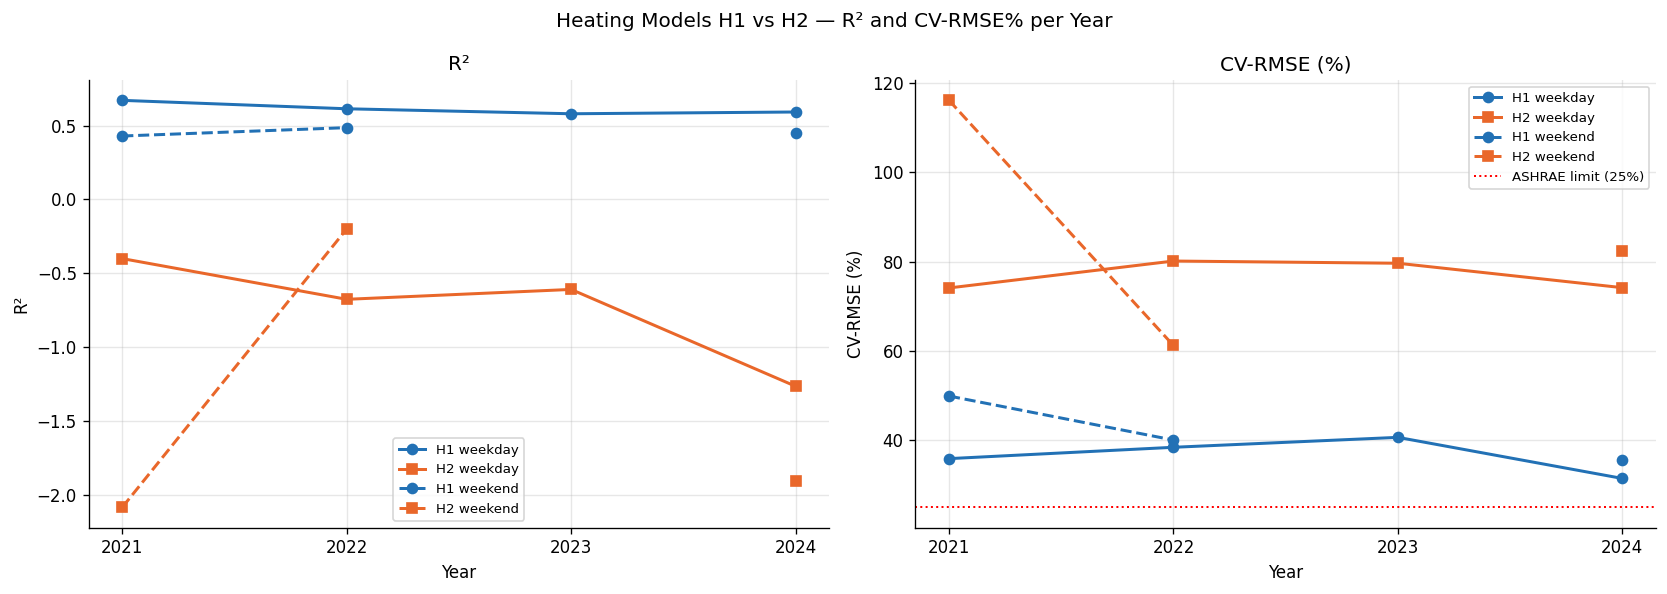

Saved: mult_heating_R2_CVRMSE.png


In [35]:
# ── R² and CV-RMSE per year: H1 vs H2 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Heating Models H1 vs H2 — R² and CV-RMSE% per Year', fontsize=12)

for ax, (metric, ylabel, threshold) in zip(
        axes,
        [('R2', 'R²', None), ('CV_RMSE_pct', 'CV-RMSE (%)', 25)]):

    for day_type in ['weekday', 'weekend']:
        for mid in ['H1', 'H2']:
            vals = []
            for yr in ind_years:
                try:
                    v = heat_results[yr][day_type][mid].get(metric, np.nan)
                except KeyError:
                    v = np.nan
                vals.append(v)
            ls  = '-'  if day_type == 'weekday' else '--'
            mk  = 'o'  if mid == 'H1'           else 's'
            ax.plot(ind_years, vals, ls=ls, marker=mk, color=COLORS[mid],
                    label=f'{mid} {day_type}', linewidth=1.8, markersize=6)

    if threshold:
        ax.axhline(threshold, color='red', linestyle=':', linewidth=1.2,
                   label=f'ASHRAE limit ({threshold}%)')
    ax.set_xlabel('Year'); ax.set_ylabel(ylabel)
    ax.set_xticks(ind_years); ax.legend(fontsize=8); ax.set_title(ylabel)

plt.tight_layout()
plt.savefig('mult_heating_R2_CVRMSE.png', bbox_inches='tight')
plt.show()
print('Saved: mult_heating_R2_CVRMSE.png')


## 13 · Export — Single Combined CSV

In [36]:
# ── Build combined cooling + heating DataFrame ──────────────────────────────
# Add energy_type column and a unified setpoint column (Tc for cooling, Th for heating)

cool_out = cool_df.copy()
cool_out['energy_type'] = 'cooling'
cool_out['setpoint']    = cool_out['Tc']          # Tc is the relevant setpoint
cool_out = cool_out.drop(columns=['Tc'], errors='ignore')

heat_out = heat_df.copy()
heat_out['energy_type'] = 'heating'
heat_out['setpoint']    = heat_out['Th']          # Th is the relevant setpoint
heat_out = heat_out.drop(columns=['Th'], errors='ignore')

# Align columns: use the union of both, filling missing with NaN
combined = pd.concat([cool_out, heat_out], ignore_index=True)

# Reorder columns for clarity
front_cols = ['energy_type', 'year', 'day_type', 'model', 'multiplicative_variable',
              'n', 'setpoint', 'Eb', 'coeff',
              'R2', 'Adj_R2', 'CV_RMSE_pct', 'NMBE_pct',
              'AIC', 'BIC', 'ASHRAE_pass']
extra_cols = [c for c in combined.columns
              if c not in front_cols and c not in ['status','Ec_actual','Ec_pred','Eh_actual','Eh_pred']]
combined = combined[[c for c in front_cols if c in combined.columns] + extra_cols]
combined = combined.sort_values(['energy_type', 'year', 'day_type', 'model']).reset_index(drop=True)

combined.to_csv('mult_models_results.csv', index=False, encoding='utf-8-sig')
print(f'Saved: mult_models_results.csv  ({len(combined)} rows)')
print()
print(f'Columns: {list(combined.columns)}')
print()
print('=== Preview ===')
display(combined[['energy_type','year','day_type','model','multiplicative_variable','n',
                   'coeff','R2','CV_RMSE_pct','NMBE_pct','ASHRAE_pass']].round(4))


Saved: mult_models_results.csv  (34 rows)

Columns: ['energy_type', 'year', 'day_type', 'model', 'multiplicative_variable', 'n', 'setpoint', 'Eb', 'coeff', 'R2', 'Adj_R2', 'CV_RMSE_pct', 'NMBE_pct', 'AIC', 'BIC', 'ASHRAE_pass']

=== Preview ===


,energy_type,year,day_type,model,multiplicative_variable,n,coeff,R2,CV_RMSE_pct,NMBE_pct,ASHRAE_pass
0,cooling,2021,weekday,C1,(Text-Tc)+ x (Text-Tint)+,36,0.3912,-0.8695,79.6944,-61.5023,False
1,cooling,2021,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,36,0.1845,0.7725,27.7974,-3.6997,False
2,cooling,2022,weekday,C1,(Text-Tc)+ x (Text-Tint)+,32,1.3451,-1.6693,114.2639,-90.3585,False
3,cooling,2022,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,32,0.2297,0.4630,51.2514,-10.9483,False
4,cooling,2022,weekend,C1,(Text-Tc)+ x (Text-Tint)+,13,0.6169,-2.4314,92.3790,-75.4409,False
5,cooling,2022,weekend,C2,(Text-Tc)+ x (Tint-Tc)+,13,0.0774,0.0773,47.9030,-17.1143,False
6,cooling,2023,weekday,C1,(Text-Tc)+ x (Text-Tint)+,57,0.7631,-1.3078,77.8658,-53.1122,False
7,cooling,2023,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,57,0.3020,0.5244,35.3469,-3.9018,False
8,cooling,2024,weekday,C1,(Text-Tc)+ x (Text-Tint)+,46,0.5462,-0.3790,55.2371,-31.1980,False
9,cooling,2024,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,46,0.3047,0.6901,26.1873,-4.7083,False


## 14 · Comparison: Multiplicative vs Best Additive

Compare new multiplicative results against the best model from the 31-model additive run.


In [37]:
add_csv = Path('cooling_31models_2020_2025.csv')

if add_csv.exists():
    add_df = pd.read_csv(add_csv)
    if 'variables' in add_df.columns:
        add_df = add_df.rename(columns={'variables': 'Variables'})
    if 'status' in add_df.columns:
        add_ok = add_df[add_df['status'] == 'OK'].copy()
    else:
        add_ok = add_df.copy()

    best_add = (add_ok.sort_values('AIC')
                .groupby(['year','day_type']).first().reset_index()
                [['year','day_type','model_no','Variables','n','R2','CV_RMSE_pct','NMBE_pct']]
                .rename(columns={'model_no':'best_add_model',
                                 'Variables':'best_add_vars',
                                 'R2':'add_R2',
                                 'CV_RMSE_pct':'add_CV',
                                 'NMBE_pct':'add_NMBE'}))
    best_add['year'] = best_add['year'].astype(str)

    cp_c = cool_df.copy(); cp_c['year'] = cp_c['year'].astype(str)
    c1 = (cp_c[cp_c['model']=='C1'][['year','day_type','R2','CV_RMSE_pct','ASHRAE_pass']]
          .rename(columns={'R2':'C1_R2','CV_RMSE_pct':'C1_CV','ASHRAE_pass':'C1_ASHRAE'}))
    c2 = (cp_c[cp_c['model']=='C2'][['year','day_type','R2','CV_RMSE_pct','ASHRAE_pass']]
          .rename(columns={'R2':'C2_R2','CV_RMSE_pct':'C2_CV','ASHRAE_pass':'C2_ASHRAE'}))

    comp = (best_add.merge(c1, on=['year','day_type'], how='outer')
                    .merge(c2, on=['year','day_type'], how='outer')
                    .sort_values(['day_type','year']))

    print('=== Cooling: Best Additive (31-model, lowest AIC) vs Multiplicative C1 / C2 ===')
    print('Equation C1: E = c·(Text-Tc)+×(Text-Tint)+')
    print('Equation C2: E = c·(Text-Tc)+×(Tint-Tc)+')
    print()
    display(comp[['year','day_type','best_add_vars','add_R2','add_CV',
                  'C1_R2','C1_CV','C1_ASHRAE',
                  'C2_R2','C2_CV','C2_ASHRAE']].round(4))
else:
    print(f'{add_csv} not found — run ECPM_31_Cooling_Models.ipynb first.')
    disp_cols = ['year','day_type','model','multiplicative_variable','R2','CV_RMSE_pct','NMBE_pct','ASHRAE_pass']
    display(cool_df[disp_cols].round(4))


cooling_31models_2020_2025.csv not found — run ECPM_31_Cooling_Models.ipynb first.


,year,day_type,model,multiplicative_variable,R2,CV_RMSE_pct,NMBE_pct,ASHRAE_pass
0,all,weekday,C1,(Text-Tc)+ x (Text-Tint)+,-0.7728,80.5606,-55.0455,False
1,all,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,0.5256,41.6755,-5.4963,False
2,all,weekend,C1,(Text-Tc)+ x (Text-Tint)+,-0.9618,94.0863,-60.3688,False
3,all,weekend,C2,(Text-Tc)+ x (Tint-Tc)+,-0.4665,81.3458,-32.5595,False
4,2021,weekday,C1,(Text-Tc)+ x (Text-Tint)+,-0.8695,79.6944,-61.5023,False
5,2021,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,0.7725,27.7974,-3.6997,False
6,2022,weekday,C1,(Text-Tc)+ x (Text-Tint)+,-1.6693,114.2639,-90.3585,False
7,2022,weekday,C2,(Text-Tc)+ x (Tint-Tc)+,0.4630,51.2514,-10.9483,False
8,2022,weekend,C1,(Text-Tc)+ x (Text-Tint)+,-2.4314,92.3790,-75.4409,False
9,2022,weekend,C2,(Text-Tc)+ x (Tint-Tc)+,0.0773,47.9030,-17.1143,False


In [38]:
# ── Heating comparison ─────────────────────────────────────────────────────────
heat_csv = Path('heating_model_results.csv')
if heat_csv.exists():
    hadd = pd.read_csv(heat_csv)
    yr_col  = 'Year'  if 'Year'     in hadd.columns else 'year'
    dt_col  = 'Day Type' if 'Day Type' in hadd.columns else 'day_type'
    hadd = hadd.rename(columns={yr_col: 'year', dt_col: 'day_type'})
    hadd['year']     = hadd['year'].astype(str)
    hadd['day_type'] = hadd['day_type'].str.lower().str.strip()

    hadd_sel = hadd[['year','day_type','R2','CV_RMSE_pct']].rename(
        columns={'R2':'orig_R2','CV_RMSE_pct':'orig_CV'})

    hp = heat_df.copy(); hp['year'] = hp['year'].astype(str)
    h1 = (hp[hp['model']=='H1'][['year','day_type','R2','CV_RMSE_pct','ASHRAE_pass']]
          .rename(columns={'R2':'H1_R2','CV_RMSE_pct':'H1_CV','ASHRAE_pass':'H1_ASHRAE'}))
    h2 = (hp[hp['model']=='H2'][['year','day_type','R2','CV_RMSE_pct','ASHRAE_pass']]
          .rename(columns={'R2':'H2_R2','CV_RMSE_pct':'H2_CV','ASHRAE_pass':'H2_ASHRAE'}))

    comp_h = (hadd_sel.merge(h1, on=['year','day_type'], how='outer')
                      .merge(h2, on=['year','day_type'], how='outer')
                      .sort_values(['day_type','year']))

    print('=== Heating: Original additive vs Multiplicative H1 / H2 ===')
    print('Equation H1: E = c·(Th-Text)+×(Tint-Text)+')
    print('Equation H2: E = c·(Th-Text)+×(Tint-Th)+')
    print()
    display(comp_h.round(4))
else:
    print(f'{heat_csv} not found.')
    disp_cols = ['year','day_type','model','multiplicative_variable','R2','CV_RMSE_pct','NMBE_pct','ASHRAE_pass']
    display(heat_df[disp_cols].round(4))


heating_model_results.csv not found.


,year,day_type,model,multiplicative_variable,R2,CV_RMSE_pct,NMBE_pct,ASHRAE_pass
0,all,weekday,H1,(Th-Text)+ x (Tint-Text)+,0.5717,39.5456,-14.9274,False
1,all,weekday,H2,(Th-Text)+ x (Tint-Th)+,-0.5840,76.0516,-23.6874,False
2,all,weekend,H1,(Th-Text)+ x (Tint-Text)+,0.3859,49.1266,-15.3794,False
3,all,weekend,H2,(Th-Text)+ x (Tint-Th)+,-2.1949,112.0550,-84.8714,False
4,2021,weekday,H1,(Th-Text)+ x (Tint-Text)+,0.6714,35.9048,-13.2415,False
5,2021,weekday,H2,(Th-Text)+ x (Tint-Th)+,-0.4009,74.1306,-17.5082,False
6,2021,weekend,H1,(Th-Text)+ x (Tint-Text)+,0.4297,49.9259,-19.3373,False
7,2021,weekend,H2,(Th-Text)+ x (Tint-Th)+,-2.0866,116.1486,-85.9796,False
8,2022,weekday,H1,(Th-Text)+ x (Tint-Text)+,0.6143,38.4446,-17.0844,False
9,2022,weekday,H2,(Th-Text)+ x (Tint-Th)+,-0.6770,80.1601,-24.6344,False
